# Jupyter Titanic

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Подготовка данных

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

#### Конкатенация по PassengerId

In [31]:
combined_df = pd.concat([train_df.set_index('PassengerId'), test_df.set_index('PassengerId')],
                       axis=0, sort=False)

#### Преобразование типов в категориальные

In [33]:
combined_df['Survived'] = combined_df['Survived'].astype('category')
combined_df['Pclass'] = combined_df['Pclass'].astype('category')
combined_df['Sex'] = combined_df['Sex'].astype('category')

print("Размер объединенного датасета:", combined_df.shape)
print("\nТипы данных:")
print(combined_df.dtypes)

Размер объединенного датасета: (1309, 11)

Типы данных:
Survived    category
Pclass      category
Name          object
Sex         category
Age          float64
SibSp          int64
Parch          int64
Ticket        object
Fare         float64
Cabin         object
Embarked      object
dtype: object


# Анализ таблицы

In [35]:
print("Базовая статистика:")
print(combined_df.describe())

Базовая статистика:
               Age        SibSp        Parch         Fare
count  1046.000000  1309.000000  1309.000000  1308.000000
mean     29.881138     0.498854     0.385027    33.295479
std      14.413493     1.041658     0.865560    51.758668
min       0.170000     0.000000     0.000000     0.000000
25%      21.000000     0.000000     0.000000     7.895800
50%      28.000000     0.000000     0.000000    14.454200
75%      39.000000     1.000000     0.000000    31.275000
max      80.000000     8.000000     9.000000   512.329200


#### В каком классе было больше всего пассажиров?

In [57]:
class_counts = combined_df['Pclass'].value_counts()
print(class_counts.idxmax())

3


Больше всего пассажиров было в классе: 3

#### Группировка по классу и полу, средний возраст

In [38]:
age_by_class_sex = combined_df.groupby(['Pclass', 'Sex'])['Age'].mean().dropna()
print("\nСредний возраст по классам и полу:")
print(age_by_class_sex)

youngest = age_by_class_sex.idxmin()
oldest = age_by_class_sex.idxmax()
age_diff = age_by_class_sex.max() - age_by_class_sex.min()

print(f"\nСамый юный: {youngest} - {age_by_class_sex.min():.1f} лет")
print(f"Самый взрослый: {oldest} - {age_by_class_sex.max():.1f} лет")
print(f"Разница: {age_diff:.1f} лет")


Средний возраст по классам и полу:
Pclass  Sex   
1       female    37.037594
        male      41.029272
2       female    27.499223
        male      30.815380
3       female    22.185329
        male      25.962264
Name: Age, dtype: float64

Самый юный: (3, 'female') - 22.2 лет
Самый взрослый: (1, 'male') - 41.0 лет
Разница: 18.8 лет


Самый юный: (3, 'female') - 22.2 лет

Самый взрослый: (1, 'male') - 41.0 лет

Разница: 18.8 лет

#### Выжившие с фамилией на "K"

In [40]:
survived_k = combined_df[
    (combined_df['Survived'] == 1) &
    (combined_df['Name'].str.contains('K.*,'))
].copy()

survived_k['Surname'] = survived_k['Name'].str.split(',').str[0]
survived_k_sorted = survived_k.sort_values('Fare', ascending=False)

print(f"\nВыжившие с фамилией на K: {len(survived_k_sorted)} человек")
print("Самый дорогой билет:")
print(survived_k_sorted[['Name', 'Fare']].head(1))
print("\nСамый дешевый билет:")
print(survived_k_sorted[['Name', 'Fare']].tail(1))


Выжившие с фамилией на K: 9 человек
Самый дорогой билет:
                                     Name     Fare
PassengerId                                       
622          Kimball, Mr. Edwin Nelson Jr  52.5542

Самый дешевый билет:
                          Name  Fare
PassengerId                         
574          Kelly, Miss. Mary  7.75


#### Самый дорогой билет
Kimball, Mr. Edwin Nelson Jr 52.5542

#### Самый дешевый билет
Kelly, Miss. Mary  7.75

#### Максимальное количество родных у выживших

In [59]:
max_relatives_survived = combined_df[combined_df['Survived'] == 1]['SibSp'].max()
print(max_relatives_survived)

4


Максимальное количество родных у выжившего: 4

# Визуализация

#### 1. Scatter plot (интерактивный)

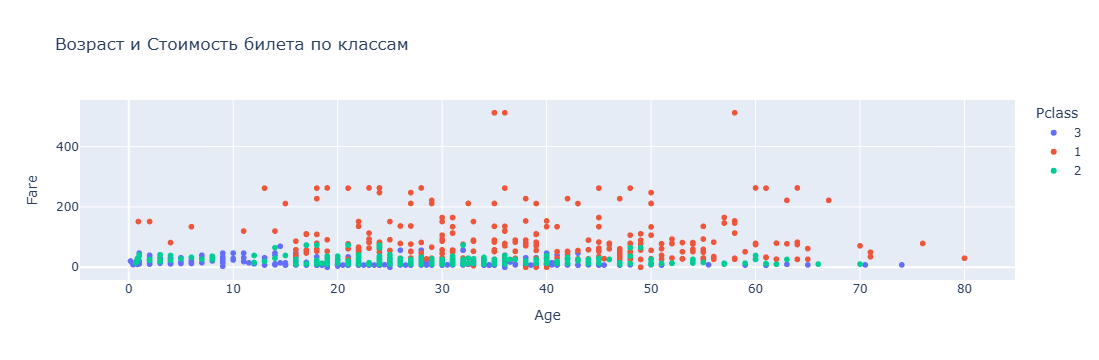

In [42]:
fig1 = px.scatter(combined_df.dropna(subset=['Age', 'Fare']),
                 x='Age', y='Fare', color='Pclass',
                 title='Возраст и Стоимость билета по классам',
                 hover_data=['Name', 'Sex'])
fig1.show()

#### 2. Linear plot with several lines

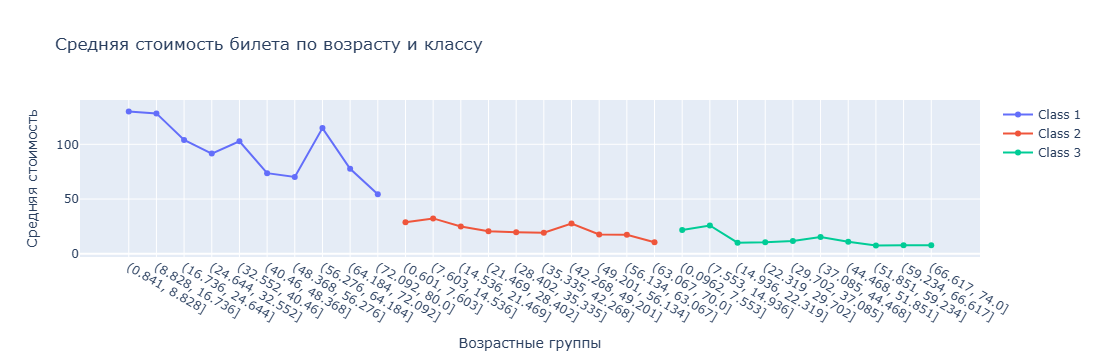

In [43]:
fig2 = go.Figure()
for pclass in [1, 2, 3]:
    class_data = combined_df[combined_df['Pclass'] == pclass]
    class_data = class_data.dropna(subset=['Age', 'Fare'])
    age_fare = class_data.groupby(pd.cut(class_data['Age'], bins=10))['Fare'].mean().dropna()
    fig2.add_trace(go.Scatter(x=age_fare.index.astype(str), y=age_fare.values,
                             mode='lines+markers', name=f'Class {pclass}'))
fig2.update_layout(title='Средняя стоимость билета по возрасту и классу',
                  xaxis_title='Возрастные группы', yaxis_title='Средняя стоимость')
fig2.show()

#### 3. Histogram

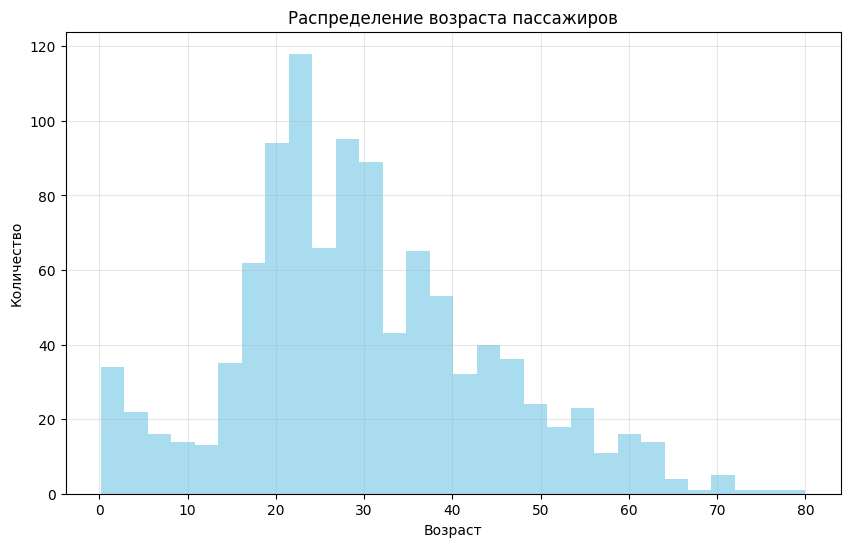

In [44]:
plt.figure(figsize=(10, 6))
combined_df['Age'].dropna().hist(bins=30, alpha=0.7, color='skyblue')
plt.title('Распределение возраста пассажиров')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.grid(alpha=0.3)
plt.show()

#### 4. Bar chart (интерактивный)

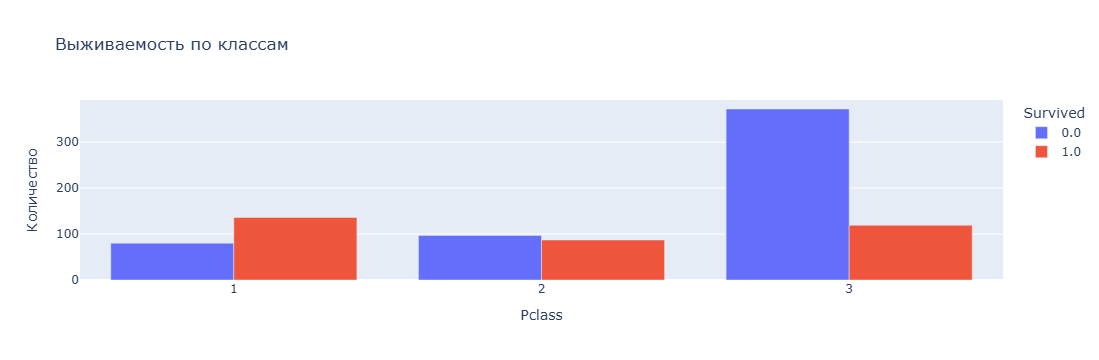

In [46]:
survival_by_class = combined_df.groupby(['Pclass', 'Survived']).size().unstack()
fig4 = px.bar(survival_by_class, barmode='group',
             title='Выживаемость по классам',
             labels={'value': 'Количество', 'variable': 'Выжил'})
fig4.show()

#### 5. Horizontal bar chart

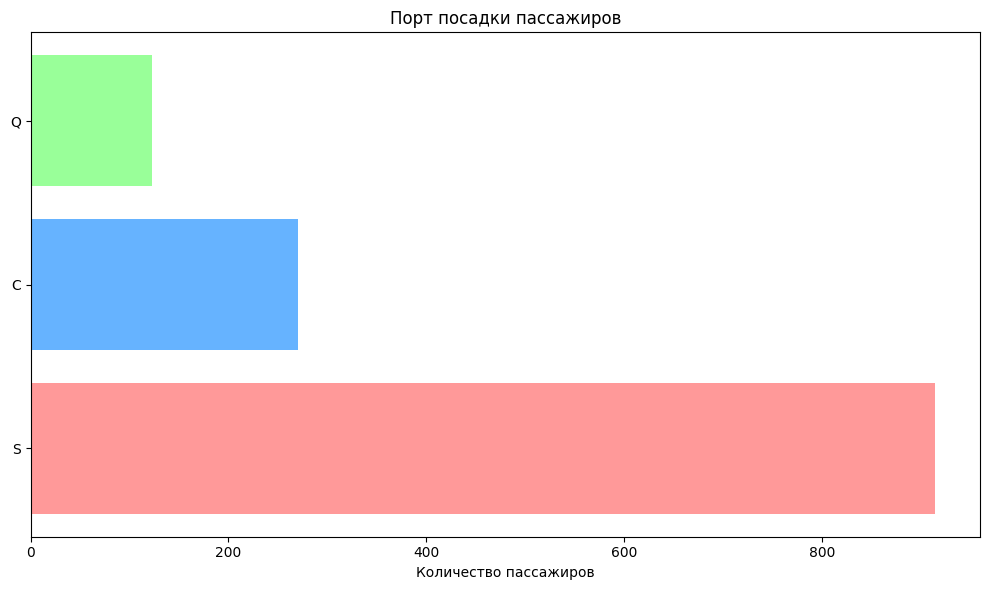

In [47]:
embarked_counts = combined_df['Embarked'].value_counts()
plt.figure(figsize=(10, 6))
plt.barh(embarked_counts.index, embarked_counts.values, color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Порт посадки пассажиров')
plt.xlabel('Количество пассажиров')
plt.tight_layout()
plt.show()

#### 6. Pie chart (интерактивный)

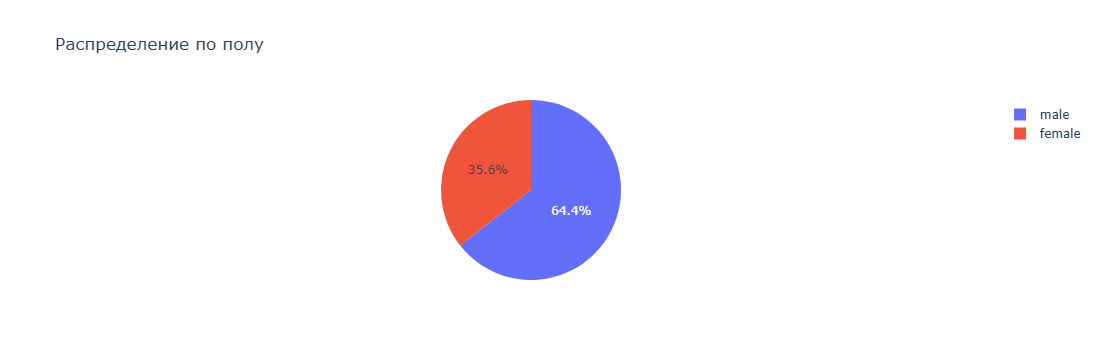

In [48]:
gender_dist = combined_df['Sex'].value_counts()
fig6 = px.pie(gender_dist, values=gender_dist.values, names=gender_dist.index,
             title='Распределение по полу')
fig6.show()

#### 7. Box chart (интерактивный)

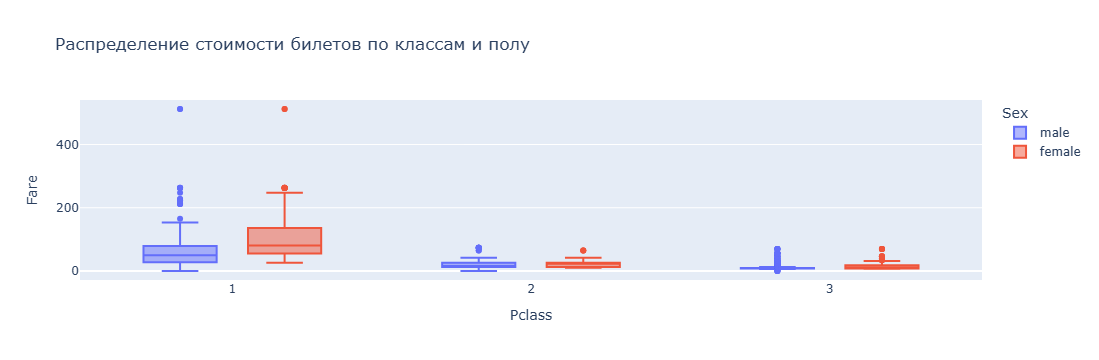

In [49]:
fig7 = px.box(combined_df, x='Pclass', y='Fare', color='Sex',
             title='Распределение стоимости билетов по классам и полу')
fig7.show()

#### 8. Sunburst chart (интерактивный)

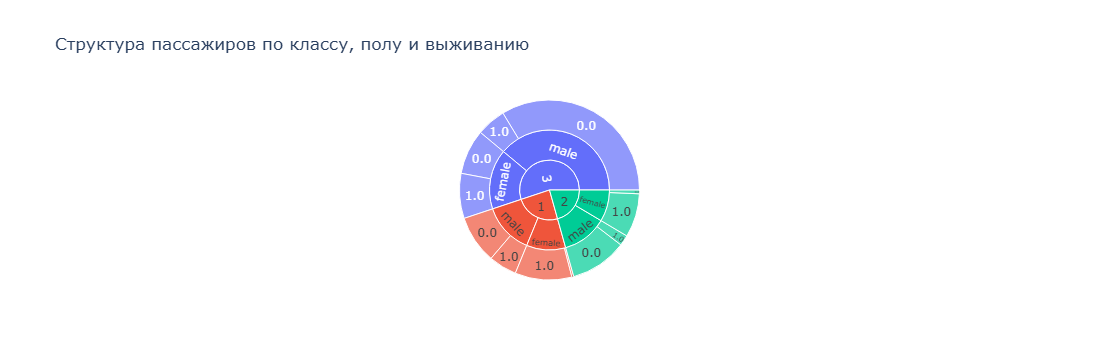

In [51]:
sunburst_data = combined_df.groupby(['Pclass', 'Sex', 'Survived']).size().reset_index(name='count')
fig8 = px.sunburst(sunburst_data, path=['Pclass', 'Sex', 'Survived'], values='count',
                  title='Структура пассажиров по классу, полу и выживанию')
fig8.show()

#### 9. 3D Scatter plot (интерактивный)

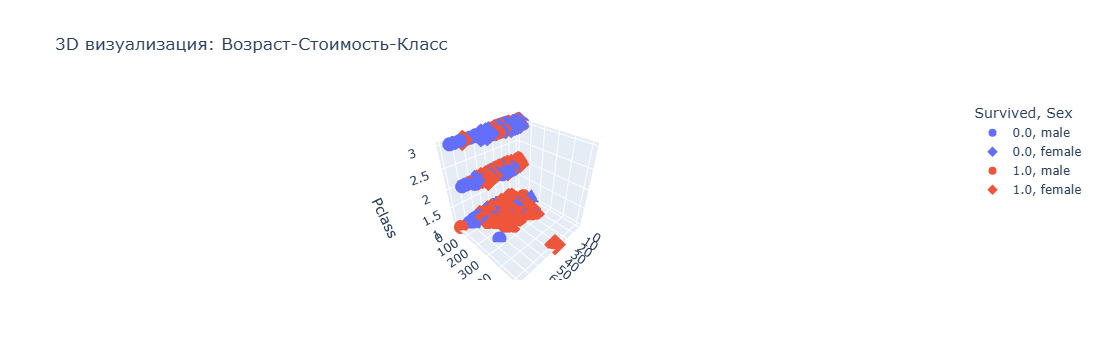

In [53]:
fig9 = px.scatter_3d(combined_df.dropna(subset=['Age', 'Fare', 'Pclass']),
                    x='Age', y='Fare', z='Pclass',
                    color='Survived', symbol='Sex',
                    title='3D визуализация: Возраст-Стоимость-Класс',
                    hover_data=['Name'])
fig9.show()

#### 10. Sankey Diagram (дополнительный)

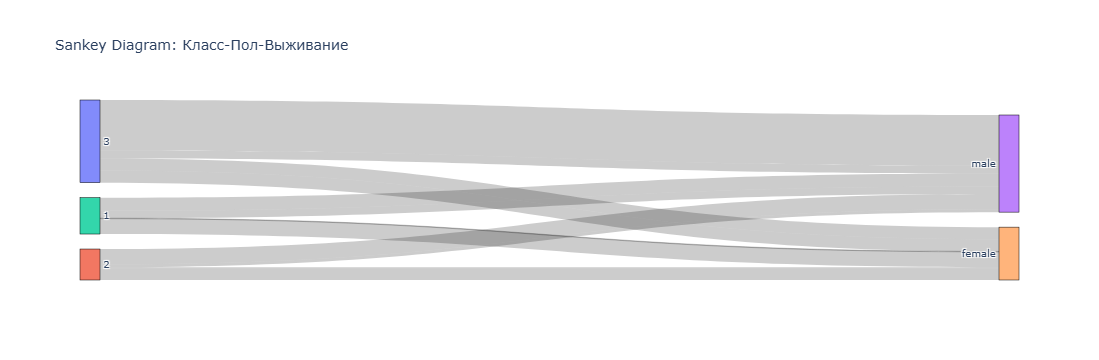

In [54]:
class_sex_survival = combined_df.groupby(['Pclass', 'Sex', 'Survived']).size().reset_index(name='count')

nodes = list(set(class_sex_survival['Pclass'].astype(str))) + \
        list(set(class_sex_survival['Sex'].astype(str))) + \
        list(set(class_sex_survival['Survived'].astype(str)))

source = []
target = []
value = []

for _, row in class_sex_survival.iterrows():
    source.append(nodes.index(str(row['Pclass'])))
    target.append(nodes.index(str(row['Sex'])))
    value.append(row['count'])

fig10 = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig10.update_layout(title_text="Sankey Diagram: Класс-Пол-Выживание", font_size=10)
fig10.show()